<details>
  <summary><strong>MIT License (click to expand)</strong></summary>

  <pre>
MIT License
Copyright (c) 2023-2026 AI Course Notebook Contributors
Repository: https://github.com/arch-inform-kaken-group/ai-course-notebooks

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
  </pre>
</details>


# 有価証券報告書の極性分析（単語の埋め込み表現とニューラルネットワークによるネガポジ分類モデル）

今回のハンズオンは，ニューラルネットワークを用いた言語（テキストデータ）の処理について，基礎を体験していただくことが目標です．

最初に，形態素解析・係り受け解析・固有表現抽出がどのようなものかを学び，次に有価証券報告書データのネガポジ分類モデルを作成します．

---

有価証券報告書とは...上場企業などが開示している企業情報のこと


## 日本語自然言語処理ライブラリGinzaのインストール

In [ ]:
!pip install -q ja_ginza==5.2.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.8 MB/s eta 0:00:00


## 自然言語処理ライブラリを使った処理の例

### SudachiPyを使った形態素解析

In [ ]:
from sudachipy import tokenizer
from sudachipy import dictionary

tokenizer_obj = dictionary.Dictionary().create()

mode = tokenizer.Tokenizer.SplitMode.C
#text = "国境の長いトンネルを抜けると雪国であった。"

text = "また利用したいと思えるホテルでした。"

morphemelist = tokenizer_obj.tokenize(text, mode)

In [ ]:
for m in morphemelist:
    print("{}\t{}\t{}\t{}\t{}\t{}".format(m.surface(),
                                      ",".join(m.part_of_speech()),
                                      m.normalized_form(),
                                      m.dictionary_form(),
                                      m.reading_form(),
                                      m.word_id()))

また	接続詞,*,*,*,*,*	又	また	マタ	148766
利用	名詞,普通名詞,サ変可能,*,*,*	利用	利用	リヨウ	316369
し	動詞,非自立可能,*,*,サ行変格,連用形-一般	為る	する	シ	67498
たい	助動詞,*,*,*,助動詞-タイ,終止形-一般	たい	たい	タイ	83573
と	助詞,格助詞,*,*,*,*	と	と	ト	102124
思える	動詞,一般,*,*,下一段-ア行,連体形-一般	思う	思える	オモエル	432076
ホテル	名詞,普通名詞,一般,*,*,*	ホテル	ホテル	ホテル	248820
でし	助動詞,*,*,*,助動詞-デス,連用形-一般	です	です	デシ	101713
た	助動詞,*,*,*,助動詞-タ,終止形-一般	た	た	タ	83558
。	補助記号,句点,*,*,*,*	。	。	。	6909


### Ginzaを使った係り受け解析

In [ ]:
import ja_ginza
import spacy
from spacy import displacy

config = {
    "components": {
        "compound_splitter": {
            "split_mode": "A"
        }
    }
}

nlp = spacy.load("ja_ginza", config=config)

doc = nlp(text)

displacy.render(doc, style="dep", jupyter=True, options={"distance": 90})

### Ginzaを使った固有表現抽出

In [ ]:
colors = {"COUNTRY":"#00cc00", "CITY":"#00cc00", "GPE_OTHER":"#00cc00","OCCASION_OTHER":"#00cc00",
          "LOCATION":"#00cc00", "LOCATION_OTHER":"#00cc00","DOMESTIC_REGION":"#00cc00","PROVINCE":"#00cc00",
          "STATION":"#00cc00", "CONTINENTAL_REGION":"#00cc00","THEATER":"#00cc00",

          "TIME":"#adff2f","DATE":"#adff2f","DAY_OF_WEEK":"#adff2f",
          "PERIOD_YEAR":"#adff2f", "PERIOD_MONTH":"#adff2f", "PERIOD_DAY":"#adff2f",

          "FLORA":"#adff99","FLORA_PART":"#adff99",
          "DISH":"#ffeb99","FOOD_OTHER":"#ffeb99",

          "AGE":"#3385ff","N_PERSON":"#3385ff","N_EVENT":"#3385ff","N_LOCATION_OTHER":"#3385ff","RANK":"#3385ff",
          "N_PRODUCT":"#3385ff","":"#3385ff","":"#3385ff","":"#3385ff","MEASUREMENT_OTHER":"#3385ff","PERCENT":"#3385ff",
          "N_ORGANIZATION":"#3385ff", "ORDINAL_NUMBER":"#3385ff", "N_FACILITY":"#3385ff","SPEED":"#3385ff",
          "PHONE_NUMBER":"#3385ff",

          "MONEY":"#ffff00",

          "COMPANY":"#99c2ff", "SCHOOL":"#99c2ff", "INTERNATIONAL_ORGANIZATION":"#99c2ff",
          "GOE_OTHER":"#99c2ff", "SHOW_ORGANIZATION":"#99c2ff","CORPORATION_OTHER":"#99c2ff",

          "CLOTHING":"#ff66a3",
          "PRODUCT_OTHER":"#ff66a3",

          "PERSON":"#c266ff",
          "POSITION_VOCATION":"#ebccff",

          "MUSIC":"#ff7f50", "MOVIE":"#ff7f50", "GAME":"#ff7f50", "SPORT":"#ff7f50", "BOOK":"#ff7f50",
          "BROADCAST_PROGRAM":"#ff7f50",

          "ANIMAL_DISEASE":"#cd5c5c"
          }

text = """
国境の長いトンネルを抜けると雪国であった。夜の底が白くなった。信号所に汽車が止まった。
　向側の座席から娘が立って来て、島村の前のガラス窓を落した。雪の冷気が流れこんだ。娘は窓いっぱいに乗り出して、遠くへ呼ぶように、
「駅長さあん、駅長さあん」
　明りをさげてゆっくり雪を踏んで来た男は、襟巻で鼻の上まで包み、耳に帽子の毛皮を垂れていた。
　もうそんな寒さかと島村は外を眺めると、鉄道の官舎らしいバラックが山裾に寒々と散らばっているだけで、雪の色はそこまで行かぬうちに闇に呑まれてい　た。
「駅長さん、私です、御機嫌よろしゅうございます」
「ああ、葉子さんじゃないか。お帰りかい。また寒くなったよ」
「弟が今度こちらに勤めさせていただいておりますのですってね。お世話さまですわ」
"""

doc = nlp(text)

displacy.render(doc, style="ent", options={"colors":colors}, jupyter=True)

## 有価証券報告書データの極性分析

### GPU の利用確認とTensorFlowのバージョン確認

In [ ]:
import locale
# 上記コードはlocalが変わるため，UTF-8に戻します．
locale.getpreferredencoding = lambda: "UTF-8"

!nvidia-smi

Tue May 19 05:51:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import tensorflow as tf
import sklearn
import os


# colab にプリインストールされていないライブラリを導入
!pip install -q japanize_matplotlib # matplotlib日本語化用の外部ライブラリ

print('TensorFlow version:',tf.__version__)
print('scikit-learn version:',sklearn.__version__)

restart_flag = False

if tf.__version__ != '2.20.0':
    !pip install -q --upgrade tensorflow==2.20.0
    print('TensorFlow version:',tf.__version__)
    restart_flag = True

if sklearn.__version__ != '1.6.1':
    !pip install -q --upgrade scikit-learn==1.6.1
    print('scikit-learn version:',sklearn.__version__)
    restart_flag = True

# 以下は，ライブラリのバージョンが変更された場合のみ実行されます．
if restart_flag :
    print("ライブラリバージョンを変更した場合に，自動でランタイムを再起動します．")
    print("colabの場合は【不明な理由でクラッシュした】旨の警告が左下に出てきますが，")
    print("これは無視しても問題ないので次以降のコードセルを実行してください．")
    # ランタイムを再起動させるために，わざとクラッシュさせています．
    get_ipython().kernel.do_shutdown(restart=True)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 71.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
TensorFlow version: 2.20.0
scikit-learn version: 1.6.1


### ライブラリのインポート

In [ ]:
from sudachipy import tokenizer # SudachiPy:日本語形態素解析器SudachiのPython版
from sudachipy import dictionary # SudachiPy:日本語形態素解析器SudachiのPython版

import os # os：標準ライブラリ，OS依存の処理（環境変数やフォルダ作成など）を扱う
import datetime # datetime：標準ライブラリ，日付関連データを扱う
import random # random：標準ライブラリ，擬似乱数発生器
import numpy as np # numpy：数値計算用ライブラリの一つ
import pandas as pd # pandas：表計算用ライブラリの一つ
from IPython.display import display # Colabなどで一部のデータをprint()よりも綺麗に出力できる関数
import matplotlib.pylab as plt # matplotlib：グラフ描画用ライブラリの一つ
import seaborn as sns # seaborn：グラフ描画用ライブラリの一つ
import tensorflow as tf # TensorFlow：深層学習ライブラリ一つ


import japanize_matplotlib # matplotlib日本語化用の外部ライブラリ

import json # json：標準ライブラリ，Pythonでjson形式のデータを扱う
import glob # glob：標準ライブラリ，ファイルパスを取得する

### 擬似乱数発生器のrandom seed 固定

* 下記プログラム中で生成・使用される擬似乱数列を固定します．
* random seed は擬似乱数列を生成する時の初期化に使われる数値です．
* 明示的に指定しない場合は，時刻などで初期化されます．
* 今回は再現性を確保する（誰がいつ実行しても同じ擬似乱数列を生成させる）ために random seed を固定します．

<small> ※ colab では割り当てられるCPU/GPUやライブラリバージョンの違いにより，完全再現は難しい場合もあります.</small>

In [ ]:
def set_seed(seed=123):
    # hash seed の固定
    os.environ["PYTHONHASHSEED"] = str(seed)
    # Python外部ライブラリ：TensorFlow の ニューラルネットワークを決定論的に動作させる
    os.environ['TF_DETERMINISTIC_OPS'] = 'true'
    # Python外部ライブラリ：TensorFlow の ニューラルネットワークを決定論的に動作させる
    os.environ['TF_CUDNN_DETERMINISTIC'] = 'true'
    # Python標準ライブラリ：random の seed固定
    random.seed(seed)
    # Python外部ライブラリ：Numpy の seed固定
    np.random.seed(seed)
    # Python外部ライブラリ：TensorFlow の seed固定
    tf.random.set_seed(seed)

set_seed(42)

### データのダウンロード
ここでは，TIS株式会社が公開している上場企業の有価証券報告書（2016年度）の極性分析（感情分析）用のデータセット，[chABSA-dataset](https://github.com/chakki-works/chABSA-dataset) を使用します．

本ノートブックでは，以下のサイトからダウンロードを行います。<br>
[kaggle] https://www.kaggle.com/datasets/takahirokubo0/chabsa

In [ ]:
# zip形式のデータセットファイルをダウンロードし，解凍を行います．
!curl -L -o /content/chABSA-dataset.zip https://www.kaggle.com/api/v1/datasets/download/takahirokubo0/chabsa
!unzip -q /content/chABSA-dataset.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1436k  100 1436k    0     0  1946k      0 --:--:-- --:--:-- --:--:-- 4299k


In [ ]:
# json ファイルを読み込み，データを見てみます．
with open("./chABSA-dataset/e00017_ann.json","br") as f:
    json_data = json.load(f)
display(json_data)

{'header': {'document_id': 'E00017',
  'document_name': '株式会社ホウスイ',
  'doc_text': '有価証券報告書',
  'edi_id': 'E00017',
  'security_code': '13520',
  'category33': '卸売業',
  'category17': '商社・卸売',
  'scale': '7'},
 'sentences': [{'sentence_id': 0,
   'sentence': '当連結会計年度におけるわが国経済は、景気は緩やかな回復基調が継続しているものの、個人消費には未だ力強さがなく、さらに英国のＥＵ離脱問題や米国のトランプ新政権発足の影響により海外経済の不確実性が高まるなど、景気の先行きについては依然不透明な状況にあります',
   'opinions': [{'target': '景気',
     'category': 'OOD#general',
     'polarity': 'positive',
     'from': 18,
     'to': 20},
    {'target': '個人消費',
     'category': 'OOD#general',
     'polarity': 'negative',
     'from': 40,
     'to': 44},
    {'target': '海外経済',
     'category': 'OOD#general',
     'polarity': 'negative',
     'from': 86,
     'to': 90},
    {'target': '先行き',
     'category': 'OOD#general',
     'polarity': 'neutral',
     'from': 105,
     'to': 108}]},
  {'sentence_id': 1,
   'sentence': '一方、水産・食品業界におきましては、消費マインドの低迷により、厳しい経営環境が続いております',
   'opinions': [{'target': '水産・食品業界',
     'cat

### 極性分析データセットの読み込み


このデータセットは，各文章中のどの部分が ネガティブ / ニュートラル / ポジティブ であるかどうかの情報が格納されています．


しかし，各文章全体に対する ネガティブ/ニュートラル/ポジティブの情報は格納されていないため，以下のコードセルで作成する処理を行います．

各文章中における，部分的なネガティブ（-1）/ポジティブ（+1）情報を合算し文章全体の ネガティブ / ポジティブ / ニュートラル を計算しています．

<br>

例：<br>
```'sentence_id':12``` の文章はポジティブの情報が3つなので「positive」，```'sentence_id':13``` の文章はポジティブとネガティブの情報が同数なので「neutral」となります．


```json
...
 {'sentence_id': 12,
   'sentence': '水産食材卸売部門においては、主要魚種の現地買付価格は上昇しましたが、円高基調や買付商品の選択、ならびに販売力の強化を図り、売上高が増大したことにより、営業利益は昨年を大きく上回りました',
   'opinions': [{'target': '水産食材卸売部門',
     'category': 'business#sales',
     'polarity': 'positive',
     'from': 0,
     'to': 8},
    {'target': '水産食材卸売部門',
     'category': 'business#profit',
     'polarity': 'positive',
     'from': 0,
     'to': 8},
    {'target': '主要魚種',
     'category': 'NULL#price',
     'polarity': 'positive',
     'from': 14,
     'to': 18}]},
  {'sentence_id': 13,
   'sentence': 'リテールサポート部門においては、既存顧客との取組みを強化し、安定した売上を確保するに至りましたが、人件費等の経費が増加したことにより、営業利益は昨年並みに留まりました',
   'opinions': [{'target': 'リテールサポート部門',
     'category': 'business#sales',
     'polarity': 'positive',
     'from': 0,
     'to': 10},
    {'target': 'リテールサポート部門',
     'category': 'business#profit',
     'polarity': 'neutral',
     'from': 0,
     'to': 10},
    {'target': '人件費等',
     'category': 'NULL#cost',
     'polarity': 'negative',
     'from': 49,
     'to': 53}]},
...
```
また，[json形式](https://ja.wikipedia.org/wiki/JavaScript_Object_Notation) のデータセットを，扱いやすいよう表形式のデータへ変換します．

In [ ]:

# 関数定義
# 各文章中における，部分的なネガティブ（-1）/ポジティブ（+1）情報を合算する．
# polarityが「neutral」（ニュートラル）であるものは，±0 として扱うため無視する．
def calc_porarity_sum(sentences):
    porarity_sum = []
    for temp in sentences:
        porarity = 0
        for opinion in temp["opinions"]:
            if opinion["polarity"] == "positive":
                porarity += 1
            elif opinion["polarity"] == "negative":
                porarity -= 1
        porarity_sum.append((porarity, temp["sentence"]))
    return porarity_sum


# 各jsonファイル群を読み込み，上の関数を使って各文章のネガティブ/ポジティブ/ニュートラル情報を作成する．
porarity_data = []
for file in glob.glob('chABSA-dataset/*.json'):
    with open(file,"br") as f:
        json_data =  json.load(f)
    porarity_data.extend(calc_porarity_sum(json_data["sentences"]))

# 部分的なネガティブ/ポジティブ情報の合算結果が，
#  0 より大きい/正数なら：ポジティブ（1）
#  0 より小さい/負数なら：ネガティブ（-1）
#  0 なら：ニュートラル（0）
dataset = []
for (porarity, sentence) in porarity_data:
    if porarity > 0:
        label = 1 #　ポジティブ
    elif porarity < 0:
        label = -1 # ネガティブ
    else:
        label = 0 # ニュートラル
    dataset.append( {'Text': sentence, 'Label': label} )


# データを表形式（pandas.DataFrame形式）へ変換
df_all = pd.DataFrame(data=dataset)
df_all.columns=['Text','Label']
df_all["Usage"] = 'train'
df_all.loc[int(len(df_all)*0.7):int(len(df_all)*0.9),"Usage"] = 'valid'
df_all.loc[int(len(df_all)*0.9):,"Usage"] =  'test'

# 数値ラベルを分かりやすいラベル名（Negative/Neutral/Positive）へ変換
df_all['Label_to_Label_names'] = df_all['Label'].map({-1:'Negative', 0:'Neutral', 1:'Positive'})

# 先頭10行を表示
display(df_all.head(10))

,Text,Label,Usage,Label_to_Label_names
0,当連結会計年度における我が国経済は、政府による経済対策や日本銀行の継続的な金融緩和を背景に、...,1,train,Positive
1,一方、海外では資源国や新興国経済の成長が鈍化し、米国新政権発足による政策変更や英国のＥＵ離脱...,-1,train,Negative
2,当社グループの属する情報サービス産業界におきましては、第４次産業革命に向けてＩｏＴ技術による...,1,train,Positive
3,企業のシステム投資が増加することにより対応する技術者への需要は拡大していますが、一方で供給が...,0,train,Neutral
4,このような環境の中、当社グループでは拡大する市場の需要へ対応すべく、新卒および中途の採用を強...,1,train,Positive
5,また、将来の持続的な発展を見据え、自社開発の住宅建設業者向けパッケージソフトウェアの全面改良...,-1,train,Negative
6,また、投資有価証券の一部を売却したことにより特別利益が発生し、税金等調整前当期純利益が増加し...,1,train,Positive
7,なお、当社グループでは従業員一人一人の健康を最大の経営資産と捉え、これまで健康増進に向け様々...,0,train,Neutral
8,"以上の結果、当連結会計年度の売上高は14,540百万円で680百万円の増加（前連結会計年度比...",1,train,Positive
9,セグメント別の業績は次のとおりであります,0,train,Neutral


### SudachiPyのトークナイザを使った分かち書き関数の定義

In [ ]:
tokenizer_obj = dictionary.Dictionary().create()

def wakati(sentence):
    mode = tokenizer.Tokenizer.SplitMode.C
    return ' '.join([m.surface() for m in tokenizer_obj.tokenize(sentence, mode)])

### 定義した分かち書き関数を'Text'列に適用

In [ ]:
df_all['Text'] = df_all['Text'].map(wakati)
display(df_all.head())

,Text,Label,Usage,Label_to_Label_names
0,当 連結 会計年度 に おけ る 我が国 経済 は 、 政府 に よる 経済 対策 や 日本...,1,train,Positive
1,一方 、 海外 で は 資源国 や 新興国 経済 の 成長 が 鈍化 し 、 米国 新 政権...,-1,train,Negative
2,当社 グループ の 属する 情報 サービス 産業界 に おき まし ては 、 第 ４ 次 産...,1,train,Positive
3,企業 の システム 投資 が 増加 する こと に より 対応 する 技術者 へ の 需要 ...,0,train,Neutral
4,この よう な 環境 の 中 、 当社 グループ で は 拡大 する 市場 の 需要 へ 対...,1,train,Positive


### 'Label'列のデータを，Negative:Neutral:Positive = -1:0:1から0:1:2に変更

In [ ]:
df_all['Label'] = df_all['Label'].map({-1:0, 0:1, 1:2})
display(df_all.head())

,Text,Label,Usage,Label_to_Label_names
0,当 連結 会計年度 に おけ る 我が国 経済 は 、 政府 に よる 経済 対策 や 日本...,2,train,Positive
1,一方 、 海外 で は 資源国 や 新興国 経済 の 成長 が 鈍化 し 、 米国 新 政権...,0,train,Negative
2,当社 グループ の 属する 情報 サービス 産業界 に おき まし ては 、 第 ４ 次 産...,2,train,Positive
3,企業 の システム 投資 が 増加 する こと に より 対応 する 技術者 へ の 需要 ...,1,train,Neutral
4,この よう な 環境 の 中 、 当社 グループ で は 拡大 する 市場 の 需要 へ 対...,2,train,Positive


### 'Usage'列を使ってデータを分割

In [ ]:
df_train = df_all[df_all['Usage'] == 'train'].copy().drop('Usage', axis=1)
df_valid = df_all[df_all['Usage'] == 'valid'].copy().drop('Usage', axis=1)
df_test = df_all[df_all['Usage'] == 'test'].copy().drop('Usage', axis=1)

#### データの件数を確認

In [ ]:
print('train:{}, dev:{}, test:{}'.format(len(df_train), len(df_valid), len(df_test)))

train:4283, dev:1224, test:612


### パラメータ設定

In [ ]:
VOCAB_SIZE = 30000  # 分析対象とする単語の最大数
MAX_LENGTH = 200     # 入力データの最大長（トークン数）
NUM_LABELS = 3      # 分類ラベルの数
EMB_DIMS = 8      # 単語埋め込み層の出力次元数
EPOCHS = 120       # 学習エポック数

### 単語を整数値に置き換えるトークナイザの定義

In [ ]:
tokenizer = tf.keras.preprocessing.text.Tokenizer(
    num_words=VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
    lower=True,
    split=' ',
    char_level=False,
    oov_token='<unk>',
    document_count=0
)

### 訓練用データでトークナイザの学習を行う

In [ ]:
tokenizer.fit_on_texts(df_train['Text'])

単語と整数値の対応を確認してみましょう．

In [ ]:
print(tokenizer.word_index)

{'<unk>': 1, '、': 2, 'の': 3, 'に': 4, 'は': 5, 'た': 6, 'と': 7, 'まし': 8, 'を': 9, 'し': 10, '円': 11, 'て': 12, 'が': 13, '）': 14, '（': 15, 'で': 16, '％': 17, 'なり': 18, '事業': 19, '比': 20, '連結': 21, '・': 22, 'より': 23, 'や': 24, 'な': 25, '「': 26, '」': 27, '会計年度': 28, '増': 29, '売上高': 30, '等': 31, '利益': 32, '前期': 33, 'ます': 34, 'する': 35, '営業': 36, 'など': 37, '前年': 38, '増加': 39, '当': 40, '減': 41, '同期': 42, 'こと': 43, 'おり': 44, '販売': 45, 'セグメント': 46, '結果': 47, '1': 48, '減少': 49, 'も': 50, '前': 51, '当社': 52, 'おい': 53, 'る': 54, 'おけ': 55, '推移': 56, '経済': 57, 'から': 58, 'また': 59, 'ては': 60, '月': 61, 'いたし': 62, 'よる': 63, '向け': 64, '2': 65, '3': 66, '関連': 67, 'グループ': 68, '同': 69, 'あり': 70, 'もの': 71, 'その': 72, 'この': 73, '及び': 74, '影響': 75, '年': 76, '市場': 77, '状況': 78, '4': 79, '\u3000': 80, '環境': 81, '5': 82, '改善': 83, '収益': 84, 'ある': 85, '8': 86, '売上': 87, '0': 88, '部門': 89, '6': 90, '業績': 91, '回復': 92, '需要': 93, 'つき': 94, '強化': 95, '比べ': 96, 'へ': 97, '9': 98, '拡大': 99, '7': 100, '平成': 101, '受注': 102, '損失': 103, 

### トークナイザを使って入力データを整数値の列に変換

In [ ]:
train_sequences = tokenizer.texts_to_sequences(df_train['Text'])
validation_sequences = tokenizer.texts_to_sequences(df_valid['Text'])
test_sequences = tokenizer.texts_to_sequences(df_test['Text'])

整数値に変換した後のテスト用データの先頭5件を見てみましょう．

In [ ]:
print(test_sequences[:5])

[[1, 15, 2551, 1562, 1395, 503, 14, 4, 94, 8, 60, 2, 853, 430, 3, 93, 9, 2203, 7, 964, 620, 6, 13, 2, 853, 430, 3, 93, 13, 1318, 4, 92, 35, 4, 1128, 969, 6, 75, 16, 2, 560, 87, 5, 1151, 49, 10, 8, 6], [1, 15, 1, 2790, 1, 401, 503, 14, 4, 94, 8, 60, 2, 87, 5, 964, 16, 56, 10, 8, 6], [101, 251, 76, 136, 61, 4, 2, 1, 3, 2916, 635, 360, 5, 1, 525, 9, 987, 10, 8, 6], [1, 89, 3, 21, 30, 5, 2, 1, 11, 15, 33, 20, 1443, 100, 17, 41, 2, 688, 21, 30, 4, 327, 630, 20, 5, 352, 82, 17, 7, 18, 8, 6], [698, 112, 89, 699]]


整数値に変換する前のテスト用データの先頭5件を見てみましょう．



In [ ]:
display(df_test.head(5))

,Text,Label,Label_to_Label_names
5507,ロボショット （ 電動 射出 成形 機 ） に つき まし ては 、 ＩＴ 関係 の 需要 ...,0,Negative
5508,ロボカット （ ワイヤ カット 放電 加工 機 ） に つき まし ては 、 売上 は 横ば...,1,Neutral
5509,平成 29 年 ３ 月 に 、 ロボカット の 累計 出荷 台数 は ３万 台 を 達成 し...,1,Neutral
5510,ロボマシン 部門 の 連結 売上高 は 、 939億39百万 円 （ 前期 比 48.7 ％...,0,Negative
5511,〔 サービス 部門 〕,1,Neutral


### 入力データの長さをMAX_LENに揃える
ここでは，padding='pre', traincating='pre'.value=0.0で，データが短い場合には先頭にゼロパディングを行い，データが長い場合には先頭から切り詰めることを指定しています．

In [ ]:
train_padded_sequences = tf.keras.preprocessing.sequence.pad_sequences(train_sequences,
                                                                       maxlen=MAX_LENGTH,
                                                                       dtype='int32',
                                                                       padding='pre',
                                                                       truncating='pre',
                                                                       value=0.0)

validation_padded_sequences = tf.keras.preprocessing.sequence.pad_sequences(validation_sequences,
                                                                       maxlen=MAX_LENGTH,
                                                                       dtype='int32',
                                                                       padding='pre',
                                                                       truncating='pre',
                                                                       value=0.0)

test_padded_sequences = tf.keras.preprocessing.sequence.pad_sequences(test_sequences,
                                                                       maxlen=MAX_LENGTH,
                                                                       dtype='int32',
                                                                       padding='pre',
                                                                       truncating='pre',
                                                                       value=0.0)

長さを揃えたテスト用データの先頭5件を見てみましょう．

In [ ]:
display( test_padded_sequences[:5] )

array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0, 

### ラベルデータの抽出

In [ ]:
train_labels = df_train['Label'].copy()
validation_labels = df_valid['Label'].copy()
test_labels = df_test['Label'].copy()

### ニューラルネットワークモデルの定義

In [ ]:
# input層（入力層）：(batch_size × MAX_LENGTH チャンネル)
inputs = tf.keras.layers.Input(shape = (MAX_LENGTH,), name = 'input')

# embedding層（埋め込み層）
# input_dim：分析対象とする単語数( Size of the vocabulary）
# output_dim：埋め込み後の次元数（Dimension of the dense embedding）
x = tf.keras.layers.Embedding(input_dim = VOCAB_SIZE, output_dim = EMB_DIMS )(inputs)

# GlobalAveragePooling層
x = tf.keras.layers.GlobalAveragePooling1D()(x)

# 全結合層
outputs = tf.keras.layers.Dense(units = NUM_LABELS, activation='softmax')(x)

# モデルを定義
model = tf.keras.Model( inputs = inputs, outputs = outputs, name = 'securities_model' )

# モデルの構造をテキストで出力
model.summary()

Model: "securities_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 8)         │       240,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 8)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,027 (937.61 KB)

 Trainable params: 240,027 (937.61 KB)

 Non-trainable params: 0 (0.00 B)

### モデルの訓練

In [ ]:
# 訓練中のログファイルを作成する準備
callbacks = []
callbacks.append(tf.keras.callbacks.CSVLogger('training_log.csv'))

# モデルのコンパイル
model.compile(optimizer=tf.keras.optimizers.Adam(2.0e-3), #最適化アルゴリズム
              loss=tf.keras.losses.CategoricalCrossentropy(), # 損失関数
              metrics=['accuracy'] #監視用の指標（モデルの訓練そのものには影響しない）
              )

# モデルの訓練（約 3 分）
history = model.fit(x = train_padded_sequences, y = tf.one_hot(train_labels.values, depth=NUM_LABELS),
                    batch_size = 256,
                    epochs = EPOCHS,
                    validation_data = (validation_padded_sequences, tf.one_hot(validation_labels.values, depth=NUM_LABELS)),
                    callbacks = callbacks
                    )

Epoch 1/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.5183 - loss: 0.9975 - val_accuracy: 0.5727 - val_loss: 0.9444
Epoch 2/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5347 - loss: 0.9810 - val_accuracy: 0.5727 - val_loss: 0.9338
Epoch 3/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5349 - loss: 0.9701 - val_accuracy: 0.5727 - val_loss: 0.9261
Epoch 4/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5361 - loss: 0.9611 - val_accuracy: 0.5768 - val_loss: 0.9162
Epoch 5/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5389 - loss: 0.9507 - val_accuracy: 0.5801 - val_loss: 0.9051
Epoch 6/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5440 - loss: 0.9384 - val_accuracy: 0.5891 - val_loss: 0.8921
Epoch 7/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5505 - loss: 0.9245 - val_accuracy: 0.5964 - val_loss: 0.8776
Epoch 8/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5571 - loss: 0.9090 - val_accuracy: 0.

### 学習経過をグラフ化

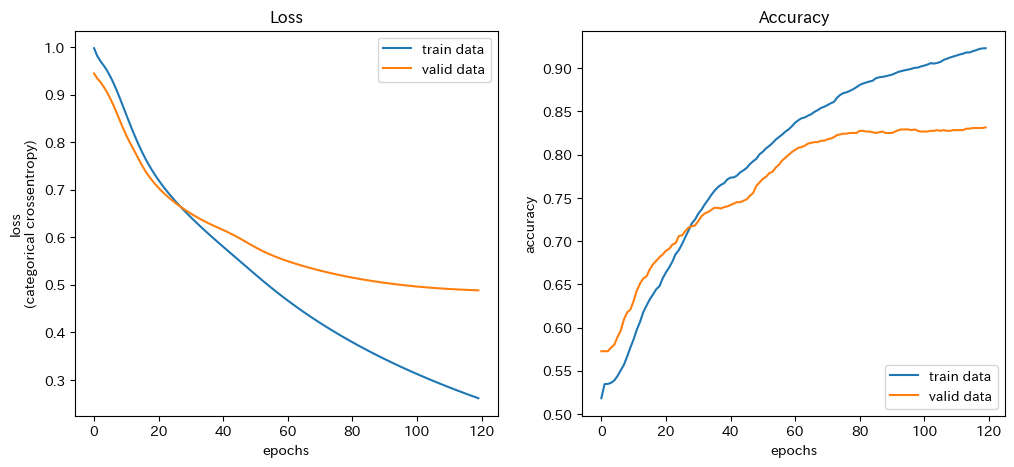

In [ ]:
# ログファイルを読み込み
log_df = pd.read_csv('training_log.csv')

epochs = log_df["epoch"].values
train_acc = log_df["accuracy"].values
train_loss = log_df["loss"].values
valid_acc = log_df["val_accuracy"].values
valid_loss = log_df["val_loss"].values

fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].plot(epochs, train_loss, label="train data")
axes[0].plot(epochs, valid_loss, label="valid data")
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss\n(categorical crossentropy)")
axes[0].legend(loc="upper right")
axes[0].set_title("Loss")

axes[1].plot(epochs, train_acc, label="train data")
axes[1].plot(epochs, valid_acc, label="valid data")
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("accuracy")
axes[1].legend(loc="lower right")
axes[1].set_title("Accuracy")

plt.show()

### テストデータを使用したモデルの評価

In [ ]:
loss, acc = model.evaluate(test_padded_sequences, tf.one_hot(test_labels, depth=NUM_LABELS))
print("\nLoss:{}, Accuracy:{}".format(loss, acc))

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8203 - loss: 0.5161

Loss:0.5160789489746094, Accuracy:0.8202614188194275


### モデルの推論結果の確認

テストデータを使ったモデルの推論結果を見てみましょう．

In [ ]:
predictions = model.predict(test_padded_sequences)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
display( predictions[:5] )

array([[0.8138573 , 0.08192572, 0.10421693],
       [0.1547703 , 0.27074048, 0.5744892 ],
       [0.07898028, 0.7000687 , 0.220951  ],
       [0.66153044, 0.16521959, 0.17324999],
       [0.0210112 , 0.9241142 , 0.05487459]], dtype=float32)

np.argmax()関数を使って出力値が最大のものを予測結果とします．

In [ ]:
df_test['Prediction'] = np.argmax(predictions, axis=1)

# モデルが推論した数値ラベルを分かりやすいラベル名（Negative/Neutral/Positive）へ変換
df_test['Prediction_to_Label_names'] = df_test['Prediction'].map({0:'Negative', 1:'Neutral', 2:'Positive'})


# 全テストデータをExcelファイルへ出力
df_test.to_excel('securities_report_text.xlsx')
# 先頭 30行 を出力
display(df_test.head(30))

,Text,Label,Label_to_Label_names,Prediction,Prediction_to_Label_names
5507,ロボショット （ 電動 射出 成形 機 ） に つき まし ては 、 ＩＴ 関係 の 需要 ...,0,Negative,0,Negative
5508,ロボカット （ ワイヤ カット 放電 加工 機 ） に つき まし ては 、 売上 は 横ば...,1,Neutral,2,Positive
5509,平成 29 年 ３ 月 に 、 ロボカット の 累計 出荷 台数 は ３万 台 を 達成 し...,1,Neutral,1,Neutral
5510,ロボマシン 部門 の 連結 売上高 は 、 939億39百万 円 （ 前期 比 48.7 ％...,0,Negative,0,Negative
5511,〔 サービス 部門 〕,1,Neutral,1,Neutral
5512,サービス に つき まし ては 、 「 サービス ・ ファースト 」 の スローガン の も...,1,Neutral,1,Neutral
5513,サービス 部門 の 連結 売上高 は 、 779億44百万 円 （ 前期 比 4.8 ％ 減...,0,Negative,0,Negative
5514,当 連結 会計年度 の わが 国 経済 は 、 底堅い 企業 収益 や 雇用 ・ 所得 環境...,2,Positive,2,Positive
5515,また 、 海外 で は 中国 を はじめ と し た 新興国 の 景気 減速 や 欧州 の ...,0,Negative,0,Negative
5516,この よう な 経済 情勢 の なか 、 物流 業 界 に おき まし て 、 国際 貨物 ...,1,Neutral,0,Negative


## 作成したモデルの途中の出力を見てみましょう

embedding 層 の出力を見るために，activation_model1を作成します．

global_average_pooling1d層の出力を見るためにactivation_model2を作成します．


In [ ]:
display( model.summary() )

Model: "securities_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 8)         │       240,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 8)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 720,083 (2.75 MB)

 Trainable params: 240,027 (937.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 480,056 (1.83 MB)

None

In [ ]:
# input層が0番目なので，1番目がembedding 層，2番目がglobal_average_pooling1d層の出力となります．
print('0番目の層')
print(model.layers[0])
print('1番目の層')
print(model.layers[1])
print('2番目の層')
print(model.layers[2])

0番目の層
<InputLayer name=input, built=True>
1番目の層
<Embedding name=embedding, built=True>
2番目の層
<GlobalAveragePooling1D name=global_average_pooling1d, built=True>


In [ ]:
# input層（入力層）：(batch_size × MAX_LENGTH チャンネル)
inputs_act1 = tf.keras.layers.Input(shape = (MAX_LENGTH,), name = 'input_act1')
# embedding 層 の出力を見る
outputs_act1 = (model.layers[1])(inputs_act1)

# activation_model1 モデル定義
activation_model1 = tf.keras.Model( inputs = inputs_act1, outputs = outputs_act1, name = 'act1_model' )


# input層（入力層）：(batch_size × MAX_LENGTH チャンネル)
inputs_act2 = tf.keras.layers.Input(shape = (MAX_LENGTH,), name = 'input_act2')
x_act2 = (model.layers[1])(inputs_act2)
# global_average_pooling1d層の出力を見る
outputs_act2 = (model.layers[2])(x_act2)

# activation_model2 モデル定義
activation_model2 = tf.keras.Model( inputs = inputs_act2, outputs = outputs_act2, name = 'act2_model' )


activation_model1，activation_model2 にテストデータを投入します．

In [ ]:
activations1 = activation_model1.predict(test_padded_sequences)
activations2 = activation_model2.predict(test_padded_sequences)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


activation_model1 に投入したテストデータの一番初めのデータを確認してみます．
embedding 層 の出力となります．

In [ ]:
print(activations1[0])

[[-0.15963933  0.1456107  -0.0340721  ...  0.08015654  0.02181605
  -0.22806036]
 [-0.15963933  0.1456107  -0.0340721  ...  0.08015654  0.02181605
  -0.22806036]
 [-0.15963933  0.1456107  -0.0340721  ...  0.08015654  0.02181605
  -0.22806036]
 ...
 [ 0.1125343  -0.7345864  -0.834616   ...  0.44080538  0.72176516
   0.35268322]
 [ 4.139727   -3.0222766  -2.807502   ... -2.0082095  -1.0241266
   4.3201604 ]
 [ 2.7634964  -1.7907716  -1.5172613  ... -1.5991802  -0.87733155
   2.8709686 ]]


activation_model2 に投入したテストデータの一番初めのデータを確認してみます．
global_average_pooling1d層の出力となります．

In [ ]:
print(activations2[0])

[ 0.08138715  0.11059029  0.01157701  0.05578427 -0.14494495 -0.0824996
 -0.11139191  0.01930892]
